In [ ]:
import torch
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import random
import gc
import time

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.backends.cudnn.deterministic = True


config = {
    'dataset': {
        'image_size': 384,
        'batch_size': 6,
        'workers': 4
    },
    'model': {
        'filters': 48,  
        'skip_connections': True
    },
    'training': {
        'epochs': 25,  
        'lr': 0.0002
    }
}

class NYUDepthDataset(Dataset): #an abstract classin pytorch that cant be initialised/ made object of so need to be inherited to use the methods
    def __init__(self, root_folder, split='train', transform=None): #constructor for the class and contains the data directory , is it train ot test and tranformations 
        self.root_folder = root_folder #storing the data directory, split type and image size  in instance variable 
        self.split = split
        self.transform = transform
        self.img_size = config['dataset']['image_size']
        #forming the path to access the images - rgb and depth maps according to my dataset 
        self.split_folder = os.path.join(root_folder, split) #contains the path for train and test folder 
        if split == 'test':
            self.split_folder = os.path.join(self.split_folder, 'official')#test folder has a additional subfolder official that is why official was added 
        
        self.rgb_files = [] #empty list but will contain the paths of the images and as a list can be acessed by indexing 
        self.depth_files = []
        
        try:
            if split == 'train':#since train folder contains subfolders named scenes 
                scene_folders = [d for d in os.listdir(self.split_folder) 
                             if os.path.isdir(os.path.join(self.split_folder, d))] #will contain the names of the scene in the train folder 
                
                for scene in scene_folders: #access indivsual scene names 
                    scene_folder = os.path.join(self.split_folder, scene) #till split_folder we had the path till the train folder now to go in the scenes , scene_folder will contain path till the scene name so inside it is structured like depth mapsssss and then startsrgb 
                    rgb_files = sorted([f for f in os.listdir(scene_folder) if f.startswith('rgb_')]) # so to differentiate into rgb and depth we check for starting name 
                    depth_files = sorted([f for f in os.listdir(scene_folder) if f.startswith('depth_')])
                    
                   
                    rgb_files = rgb_files[::3] #taking every 3rd image from the dataset the dataset contain around 90000+ images will be too much to train
                    depth_files = depth_files[::3]#contains the name of the rgb and depth images
                    
                    self.rgb_files.extend([os.path.join(scene_folder, f) for f in rgb_files]) #now it contains the whole path to the image and 
                    #will be accessible even outside the loop
                    self.depth_files.extend([os.path.join(scene_folder, f) for f in depth_files])
                    
            else:#if the split value is test then 
                self.rgb_files = sorted([os.path.join(self.split_folder, f) for f in os.listdir(self.split_folder) 
                                        if f.startswith('rgb_')])
                self.depth_files = sorted([os.path.join(self.split_folder, f) for f in os.listdir(self.split_folder) 
                                          if f.startswith('depth_')])
            
            assert len(self.rgb_files) == len(self.depth_files) 
            print("equal image pairs")
            
        except Exception as e:
            print(f"Error initializing dataset: {str(e)}")
            self.rgb_files = []
            self.depth_files = []
        
    def __len__(self):
        return len(self.rgb_files) #number of sample in the list- coumtimg only rgb files as thee is corresponding depth file to each rgb file 

    def __getitem__(self, idx): #the index is automatically handled by dataloader-pytorch increments it
        try:
            rgb_path = self.rgb_files[idx] #is a list containg the paths of the images 
            depth_path = self.depth_files[idx]
                
            #RGB image
            rgb = cv2.imread(rgb_path)
            rgb = cv2.cvtColor(rgb, cv2.COLOR_BGR2RGB)
            
            #depth image
            depth = cv2.imread(depth_path, cv2.IMREAD_GRAYSCALE) #opencv reads the depth image as a 3 channel gray image cintaing all the 3 same channels and to work with tensors we require 1 channel gray images 
            
            # Resize to make it even and all the images the same size , added interpolation - which predits the pixel if it is not present while resizing - used INTER_CUBIC which works on the neighbouring 16 pixels (4 x 4) grid
            rgb = cv2.resize(rgb, (self.img_size, self.img_size), interpolation=cv2.INTER_CUBIC)
            depth = cv2.resize(depth, (self.img_size, self.img_size), interpolation=cv2.INTER_CUBIC)
            
            # tensors- pytorch functions work on tensors and not numpy arrays 
            rgb = torch.from_numpy(rgb).float().permute(2, 0, 1) / 255.0
            depth = torch.from_numpy(depth).float().unsqueeze(0) / 255.0
            
            # data augumentaion to make the data sample more diverse 
            if self.split == 'train' and random.random() > 0.5:
                # horizontal flipping
                rgb = torch.flip(rgb, dims=[2])
                depth = torch.flip(depth, dims=[2]) #dim=2 it is flipped from left to right if had been 1 or -2 then vertically
            
            return rgb, depth
        except Exception as e:
            print(f"Error processing image at index {idx}: {str(e)}")
            # Return a placeholder image instead of crashing
            placeholder_rgb = torch.zeros(3, self.img_size, self.img_size)
            placeholder_depth = torch.zeros(1, self.img_size, self.img_size)
            return placeholder_rgb, placeholder_depth
            
class ImprovedDepthModel(nn.Module):
    def __init__(self):
        super(ImprovedDepthModel, self).__init__()
        
        # Encoder part with more filters and double convolutions
        self.down1 = nn.Sequential(
            nn.Conv2d(3, config['model']['filters'], kernel_size=7, stride=2, padding=3),
            nn.BatchNorm2d(config['model']['filters']),
            nn.ReLU(inplace=True),
            nn.Conv2d(config['model']['filters'], config['model']['filters'], kernel_size=3, padding=1),
            nn.BatchNorm2d(config['model']['filters']),
            nn.ReLU(inplace=True)
        )
        self.pool1 = nn.MaxPool2d(2)
        
        self.down2 = nn.Sequential(
            nn.Conv2d(config['model']['filters'], config['model']['filters']*2, kernel_size=3, padding=1),
            nn.BatchNorm2d(config['model']['filters']*2),
            nn.ReLU(inplace=True),
            nn.Conv2d(config['model']['filters']*2, config['model']['filters']*2, kernel_size=3, padding=1),
            nn.BatchNorm2d(config['model']['filters']*2),
            nn.ReLU(inplace=True)
        )
        self.pool2 = nn.MaxPool2d(2)
        
        self.down3 = nn.Sequential(
            nn.Conv2d(config['model']['filters']*2, config['model']['filters']*4, kernel_size=3, padding=1),
            nn.BatchNorm2d(config['model']['filters']*4),
            nn.ReLU(inplace=True),
            nn.Conv2d(config['model']['filters']*4, config['model']['filters']*4, kernel_size=3, padding=1),
            nn.BatchNorm2d(config['model']['filters']*4),
            nn.ReLU(inplace=True)
        )
        self.pool3 = nn.MaxPool2d(2)
        
        self.down4 = nn.Sequential(
            nn.Conv2d(config['model']['filters']*4, config['model']['filters']*8, kernel_size=3, padding=1),
            nn.BatchNorm2d(config['model']['filters']*8),
            nn.ReLU(inplace=True),
            nn.Conv2d(config['model']['filters']*8, config['model']['filters']*8, kernel_size=3, padding=1),
            nn.BatchNorm2d(config['model']['filters']*8),
            nn.ReLU(inplace=True)
        )
        self.pool4 = nn.MaxPool2d(2)
        
        # Bottleneck
        self.bottleneck = nn.Sequential(
            nn.Conv2d(config['model']['filters']*8, config['model']['filters']*16, kernel_size=3, padding=1),
            nn.BatchNorm2d(config['model']['filters']*16),
            nn.ReLU(inplace=True),
            nn.Conv2d(config['model']['filters']*16, config['model']['filters']*16, kernel_size=3, padding=1),
            nn.BatchNorm2d(config['model']['filters']*16),
            nn.ReLU(inplace=True)
        )
        
        # Decoder part with better upsampling and double convolutions
        self.up4 = nn.ConvTranspose2d(config['model']['filters']*16, config['model']['filters']*8, kernel_size=4, stride=2, padding=1)
        self.conv4 = nn.Sequential(
            nn.Conv2d(config['model']['filters']*16, config['model']['filters']*8, kernel_size=3, padding=1),
            nn.BatchNorm2d(config['model']['filters']*8),
            nn.ReLU(inplace=True),
            nn.Conv2d(config['model']['filters']*8, config['model']['filters']*8, kernel_size=3, padding=1),
            nn.BatchNorm2d(config['model']['filters']*8),
            nn.ReLU(inplace=True)
        )
        
        self.up3 = nn.ConvTranspose2d(config['model']['filters']*8, config['model']['filters']*4, kernel_size=4, stride=2, padding=1)
        self.conv3 = nn.Sequential(
            nn.Conv2d(config['model']['filters']*8, config['model']['filters']*4, kernel_size=3, padding=1),
            nn.BatchNorm2d(config['model']['filters']*4),
            nn.ReLU(inplace=True),
            nn.Conv2d(config['model']['filters']*4, config['model']['filters']*4, kernel_size=3, padding=1),
            nn.BatchNorm2d(config['model']['filters']*4),
            nn.ReLU(inplace=True)
        )
        
        self.up2 = nn.ConvTranspose2d(config['model']['filters']*4, config['model']['filters']*2, kernel_size=4, stride=2, padding=1)
        self.conv2 = nn.Sequential(
            nn.Conv2d(config['model']['filters']*4, config['model']['filters']*2, kernel_size=3, padding=1),
            nn.BatchNorm2d(config['model']['filters']*2),
            nn.ReLU(inplace=True),
            nn.Conv2d(config['model']['filters']*2, config['model']['filters']*2, kernel_size=3, padding=1),
            nn.BatchNorm2d(config['model']['filters']*2),
            nn.ReLU(inplace=True)
        )
        
        self.up1 = nn.ConvTranspose2d(config['model']['filters']*2, config['model']['filters'], kernel_size=4, stride=2, padding=1)
        self.conv1 = nn.Sequential(
            nn.Conv2d(config['model']['filters']*2, config['model']['filters'], kernel_size=3, padding=1),
            nn.BatchNorm2d(config['model']['filters']),
            nn.ReLU(inplace=True),
            nn.Conv2d(config['model']['filters'], config['model']['filters'], kernel_size=3, padding=1),
            nn.BatchNorm2d(config['model']['filters']),
            nn.ReLU(inplace=True)
        )
        
        # Output layer with more refinement
        self.output = nn.Sequential(
            nn.Conv2d(config['model']['filters'], config['model']['filters']//2, kernel_size=3, padding=1),
            nn.BatchNorm2d(config['model']['filters']//2),
            nn.ReLU(inplace=True),
            nn.Conv2d(config['model']['filters']//2, config['model']['filters']//4, kernel_size=3, padding=1),
            nn.BatchNorm2d(config['model']['filters']//4),
            nn.ReLU(inplace=True),
            nn.Conv2d(config['model']['filters']//4, 1, kernel_size=1),
            nn.Sigmoid()
        )
        
        # Initialize weights for better training
        self._init_weights()
    
    def _init_weights(self):
        # Simple weight initialization that helps training
        for m in self.modules():
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.ConvTranspose2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        # Encoder path
        d1 = self.down1(x)
        p1 = self.pool1(d1)
        
        d2 = self.down2(p1)
        p2 = self.pool2(d2)
        
        d3 = self.down3(p2)
        p3 = self.pool3(d3)
        
        d4 = self.down4(p3)
        p4 = self.pool4(d4)
        
        # Bottleneck
        b = self.bottleneck(p4)
        
        # Decoder path with skip connections
        u4 = self.up4(b)
        u4 = torch.cat([u4, d4], dim=1)
        c4 = self.conv4(u4)
        
        u3 = self.up3(c4)
        u3 = torch.cat([u3, d3], dim=1)
        c3 = self.conv3(u3)
        
        u2 = self.up2(c3)
        u2 = torch.cat([u2, d2], dim=1)
        c2 = self.conv2(u2)
        
        u1 = self.up1(c2)
        u1 = torch.cat([u1, d1], dim=1)
        c1 = self.conv1(u1)
        
        # Final output
        out = self.output(c1)
        
        return out

def find_dataset(base_dirs):
    for base_dir in base_dirs:
        if (os.path.exists(os.path.join(base_dir, 'train')) and 
            os.path.exists(os.path.join(base_dir, 'test'))):
            return base_dir
        
        if os.path.isdir(base_dir):
            for subdir in os.listdir(base_dir):
                subdir_path = os.path.join(base_dir, subdir)
                if not os.path.isdir(subdir_path):
                    continue
                    
                if (os.path.exists(os.path.join(subdir_path, 'train')) and 
                    os.path.exists(os.path.join(subdir_path, 'test'))):
                    return subdir_path
    return None

def better_enhance_depth(depth):
    """
    Enhanced depth map enhancement that preserves edges and reduces blocky artifacts
    """
    # Step 1: Normalize depth map
    depth_min = depth.min()
    depth_max = depth.max()
    if depth_max > depth_min:
        depth = (depth - depth_min) / (depth_max - depth_min)
    
    try:
        # Step 2: Apply bilateral filter to smooth while preserving edges
        # This is key to reducing the "boxy" artifacts
        depth_smooth = cv2.bilateralFilter(depth.astype(np.float32), d=7, sigmaColor=0.1, sigmaSpace=5)
        
        # Step 3: Convert to uint8 for processing
        depth_uint8 = (depth_smooth * 255).astype(np.uint8)
        
        # Step 4: Enhance local contrast with CLAHE
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        depth_contrast = clahe.apply(depth_uint8)
        depth_contrast = depth_contrast.astype(np.float32) / 255.0
        
        # Step 5: Enhance edges to make objects more visible
        kernel_edge = np.array([[0, -1, 0], 
                                [-1, 5, -1], 
                                [0, -1, 0]], dtype=np.float32)
        depth_edge = cv2.filter2D(depth_contrast, -1, kernel_edge)
        
        # Step 6: Blend original and enhanced versions
        depth_blend = 0.7 * depth_edge + 0.3 * depth_smooth
        
        # Step 7: Final gentle smoothing to reduce any noise
        depth_final = cv2.GaussianBlur(depth_blend, (3, 3), 0.5)
        
    except Exception as e:
        print(f"Error in depth enhancement: {e}")
        depth_final = depth  # Fallback to original if enhancement fails
    
    return np.clip(depth_final, 0, 1)

def train_model(model, train_loader, val_loader, device, num_epochs=30, lr=0.0002, start_epoch=0):
    def improved_depth_loss(pred, target):
        # Ensure same size
        if pred.size() != target.size():
            target = F.interpolate(target, size=pred.size()[2:], mode='bilinear', align_corners=True)
        
        # Basic L1 loss
        l1_loss = F.l1_loss(pred, target)
        
        try:
            # Edge-aware loss components
            sobel_x = torch.tensor([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=torch.float32, device=device).view(1, 1, 3, 3)
            sobel_y = torch.tensor([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=torch.float32, device=device).view(1, 1, 3, 3)
            
            # Gradient loss to preserve edges
            pred_grad_x = F.conv2d(pred, sobel_x, padding=1)
            pred_grad_y = F.conv2d(pred, sobel_y, padding=1)
            target_grad_x = F.conv2d(target, sobel_x, padding=1)
            target_grad_y = F.conv2d(target, sobel_y, padding=1)
            
            grad_loss = F.l1_loss(pred_grad_x, target_grad_x) + F.l1_loss(pred_grad_y, target_grad_y)
            
            # Add simple smoothness loss to reduce "boxy" artifacts
            pred_dx = torch.abs(pred[:, :, :, :-1] - pred[:, :, :, 1:])
            pred_dy = torch.abs(pred[:, :, :-1, :] - pred[:, :, 1:, :])
            smooth_loss = torch.mean(pred_dx) + torch.mean(pred_dy)
            
            # Combine all losses with weights
            total_loss = 0.7 * l1_loss + 0.2 * grad_loss + 0.1 * smooth_loss
        except Exception as e:
            print(f"Loss calculation error: {e}, using basic L1 loss")
            total_loss = l1_loss
        
        return total_loss
    
    # Use AdamW instead of Adam for better weight decay handling
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    
    # LR scheduler
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=4)
    
    best_loss = float('inf')
    best_model_path = 'best_depth_model.pth'
    
    for epoch in range(start_epoch, num_epochs):
        epoch_start_time = time.time()
        
        # Training phase
        model.train()
        train_loss = 0
        train_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]',bar_format='{l_bar}{bar}|{n_fmt}/{total_fmt}[{postfix}]')
        
        for batch_idx, (rgb, depth) in enumerate(train_bar):
            try:
                rgb, depth = rgb.to(device), depth.to(device)
                
                # Forward pass
                optimizer.zero_grad()
                pred_depth = model(rgb)
                
                # Calculate loss
                loss = improved_depth_loss(pred_depth, depth)
                
                # Backward pass
                loss.backward()
                
                # Gradient clipping to prevent exploding gradients
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                
                # Update weights
                optimizer.step()
                
                # Update running loss
                train_loss += loss.item()
                train_bar.set_postfix({'loss': loss.item()})
                
            except Exception as e:
                print(f"Error in batch: {e}")
                continue
                
        # Calculate average training loss
        train_loss /= len(train_loader)
        
        # Clear memory- session timed out
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            
        # Validation phase
        model.eval()
        val_loss = 0
        
        with torch.no_grad():
            for rgb, depth in tqdm(val_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Val]'):
                rgb, depth = rgb.to(device), depth.to(device)
                pred_depth = model(rgb)
                loss = improved_depth_loss(pred_depth, depth)
                val_loss += loss.item()
        
        # Calculate average validation loss
        val_loss /= len(val_loader)
        
        # Update learning rate
        scheduler.step(val_loss)
        
        
        # Print epoch results
        print(f'\nEpoch {epoch+1}/{num_epochs}:')
        print(f'Training Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}')
        
        # Save best model
        if val_loss < best_loss:
            best_loss = val_loss
            torch.save(model.state_dict(), best_model_path)
            print(f"Best model saved with validation loss {val_loss:.4f}")

    print("Training completed!")

    if os.path.exists('/kaggle'):
        try:
            from IPython.display import FileLink
            display(FileLink(best_model_path))
            print(f"link to download your BEST model (val_loss: {best_loss:.4f})")
        except:
            pass

    return model, best_model_path
    
def main():
    set_seed(42)
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using {device}")
    
    # Use our improved model
    model = ImprovedDepthModel().to(device)
    
    possible_paths = []
    if os.path.exists('/kaggle/input'):
        for dataset in os.listdir('/kaggle/input'):
            possible_paths.append(os.path.join('/kaggle/input', dataset))
        possible_paths.append('/kaggle/input')
    
    root_folder = find_dataset(possible_paths)
    if root_folder is None:
        print("Dataset not found. Please check the path.")
        return
        
    print(f"Found dataset at: {root_folder}")
    
    train_dataset = NYUDepthDataset(root_folder, split='train')
    val_dataset = NYUDepthDataset(root_folder, split='test')
    
    if len(train_dataset) == 0 or len(val_dataset) == 0:
        print("Empty dataset found")
        return
    
    train_loader = DataLoader(
        train_dataset,
        batch_size=config['dataset']['batch_size'],
        shuffle=True,
        num_workers=config['dataset']['workers'],
        drop_last=True,
        pin_memory=True
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=config['dataset']['batch_size'],
        shuffle=False,
        num_workers=config['dataset']['workers'],
        drop_last=False,
        pin_memory=True
    )
    
    print(f"Created data loaders - Train: {len(train_loader)} batches, Validation: {len(val_loader)} batches")
    
    start_epoch = 14
    
    print("\n=== Starting Training ===")
    model, best_model_path = train_model(
        model,
        train_loader,
        val_loader,
        device,
        num_epochs=config['training']['epochs'],
        lr=config['training']['lr'],
        start_epoch=start_epoch
    )
    
    if os.path.exists(best_model_path):
        model.load_state_dict(torch.load(best_model_path))
        print("Best model loaded")
    
    if os.path.exists('simple_depth_model.pth'):
        print("Model ready for use")
    
    print("\n=== Model Ready for Depth Estimation ===")

if __name__ == '__main__':
    main()


Using cuda
Found dataset at: /kaggle/input/nyuv2-official-split-dataset
Found 15964 train image pairs
Found 109 test image pairs
Starting training from scratch

=== Starting Training ===


<ipython-input-17-c768ba0c2b6f>:558: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('checkpoint.pth'))


Initial model saved


Epoch 1/30 [Train]: 100%|██████████| 2660/2660 [10:42<00:00,  4.14it/s, loss=0.0924]



Epoch 1/30:
Training Loss: 0.0889, Validation Loss: 0.0759
Best model saved with validation loss 0.0759


...

Epoch 29/30 [Train]: 100%|██████████| 2660/2660 [10:45<00:00,  4.12it/s, loss=0.0197]



Epoch 29/30:
Training Loss: 0.0235, Validation Loss: 0.0554
No improvement for 5 epochs


Epoch 30/30 [Train]: 100%|██████████| 2660/2660 [10:44<00:00,  4.12it/s, loss=0.0216]



Epoch 30/30:
Training Loss: 0.0216, Validation Loss: 0.0549
Best model saved with validation loss 0.0549
Training completed!
Best model loaded
Model ready for use

=== Model Ready for Depth Estimation ===


<ipython-input-17-c768ba0c2b6f>:576: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path))


Using device: cuda
Starting depth estimation process...


<ipython-input-18-7593f932e0d1>:189: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('simple_depth_model.pth', map_location=device))


Model loaded successfully

Depth Estimation Options:
1. Process sample images
2. Process custom image(s)
3. Exit


Enter choice (1-3):  1



Processing sample images from dataset

Checking directory: /kaggle/input/nyuv2-official-split-dataset/test/official
Found 1308 images

Processing image 1/5: rgb_00697.png


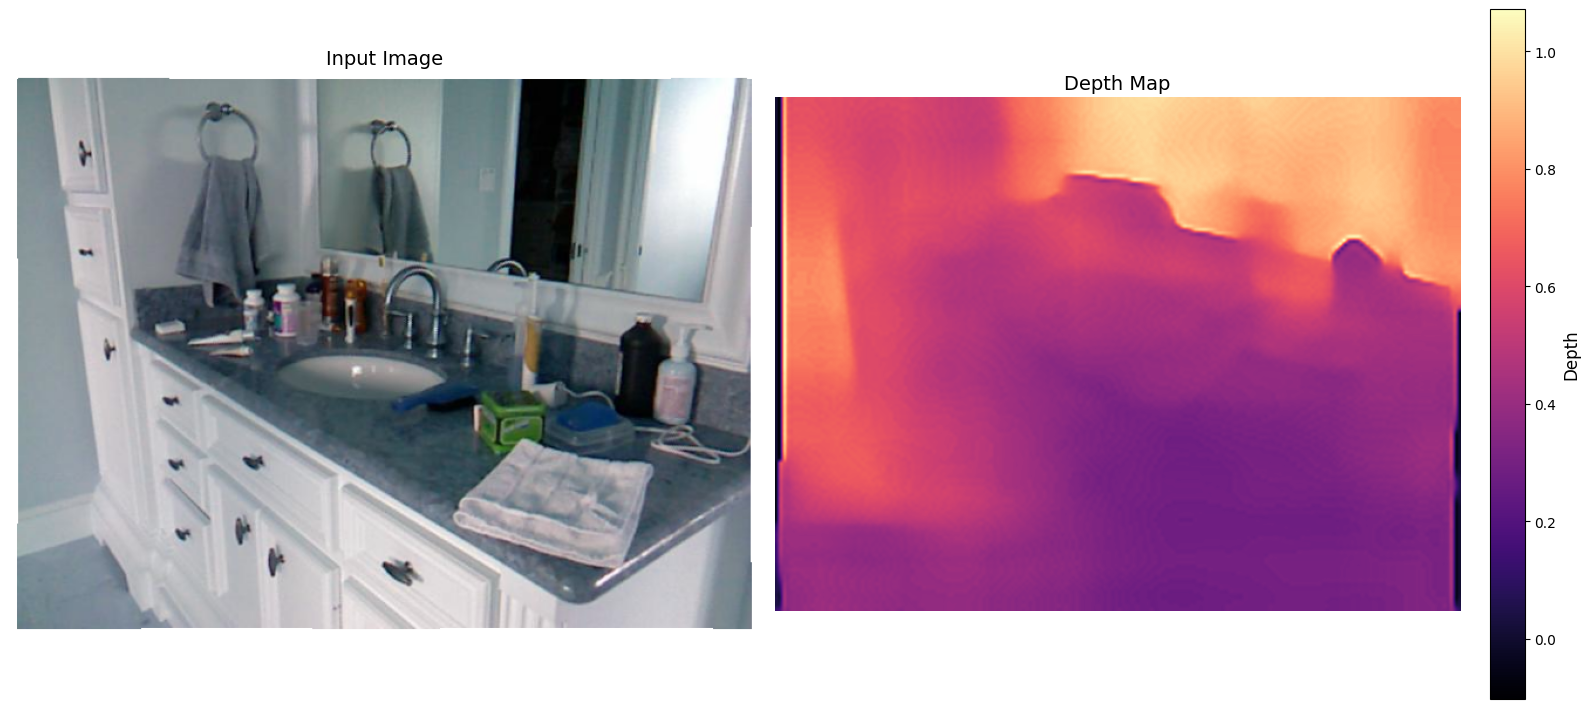

Results saved to depth_result_1.png and depth_only_1.png

Processing image 2/5: depth_00033.png


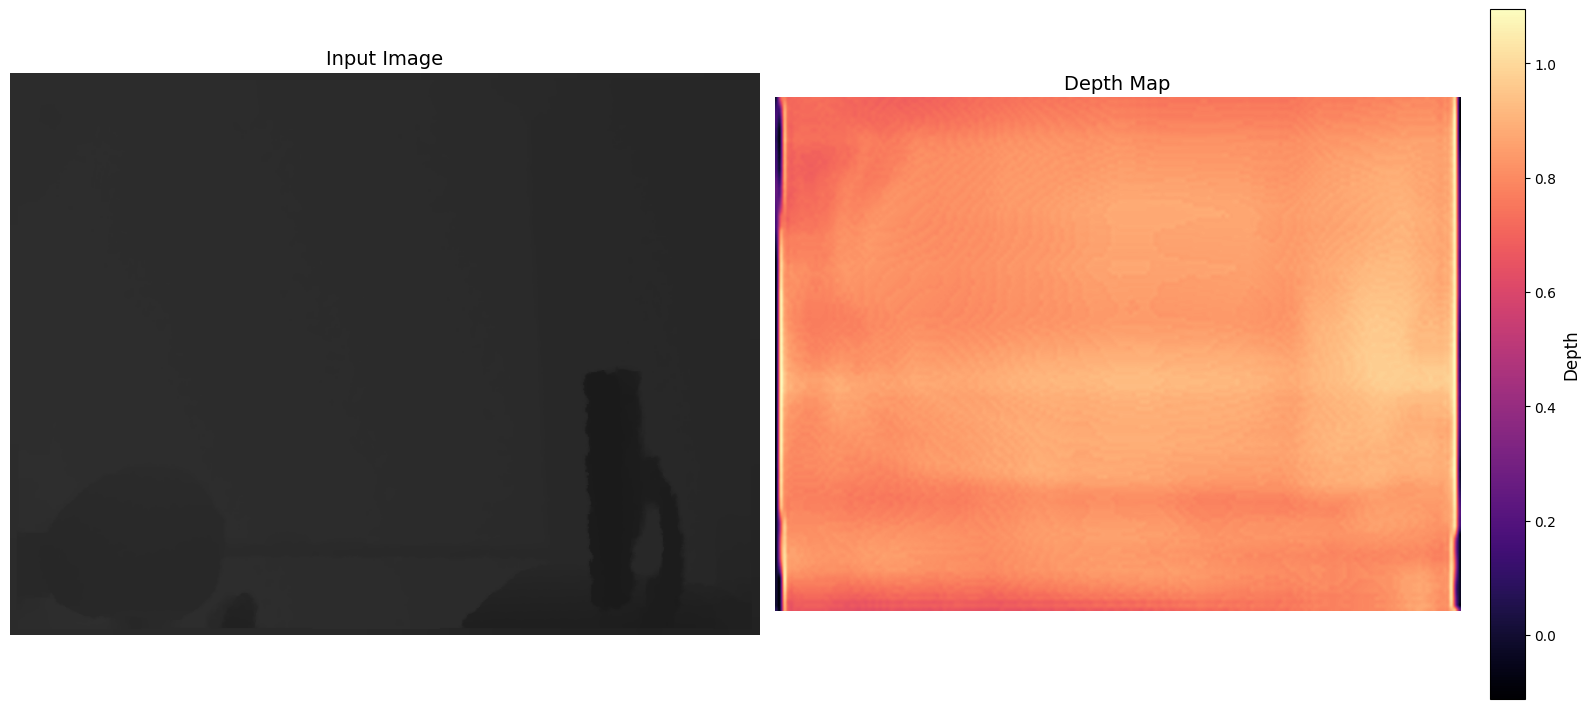

Results saved to depth_result_2.png and depth_only_2.png

Processing image 3/5: rgb_00549.png


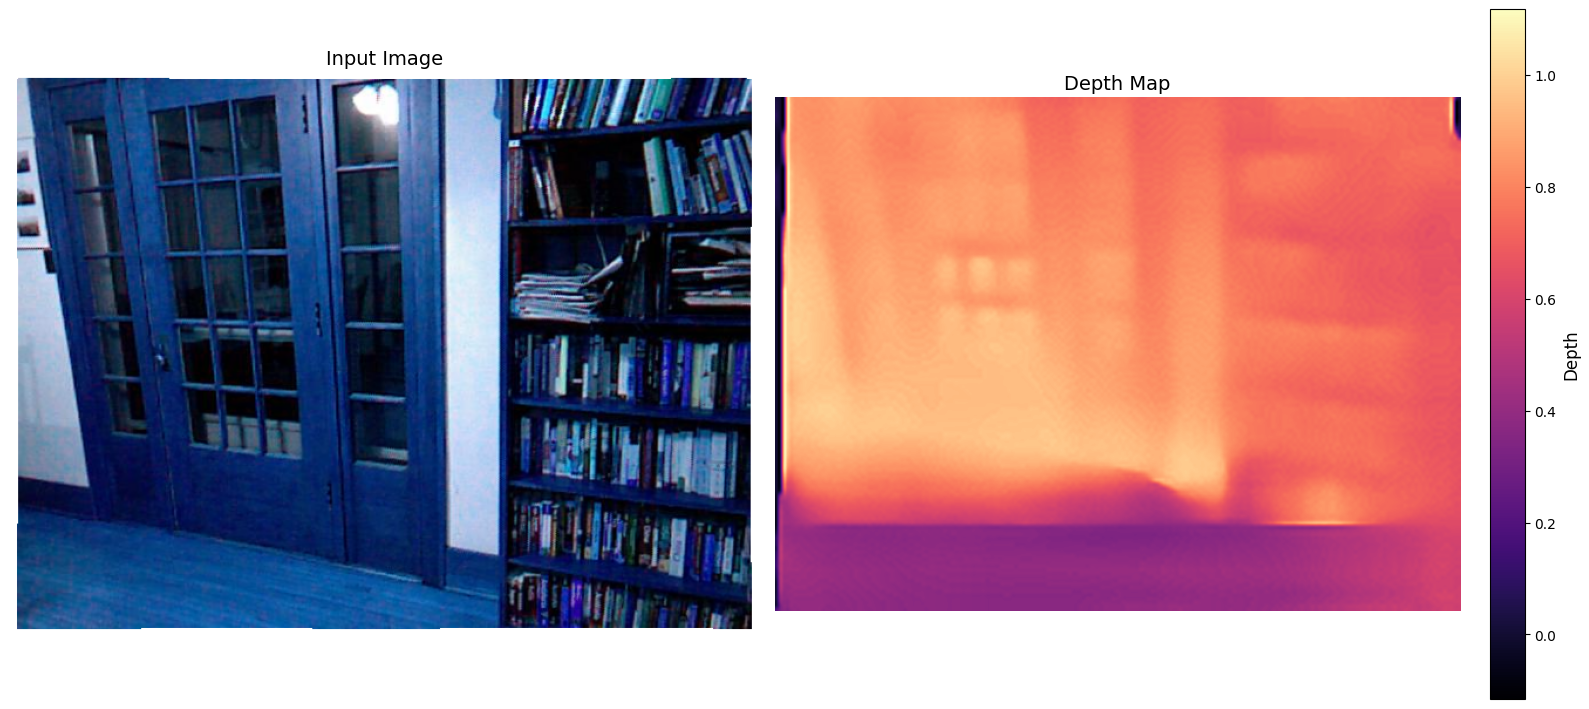

Results saved to depth_result_3.png and depth_only_3.png

Processing image 4/5: rgb_01349.png


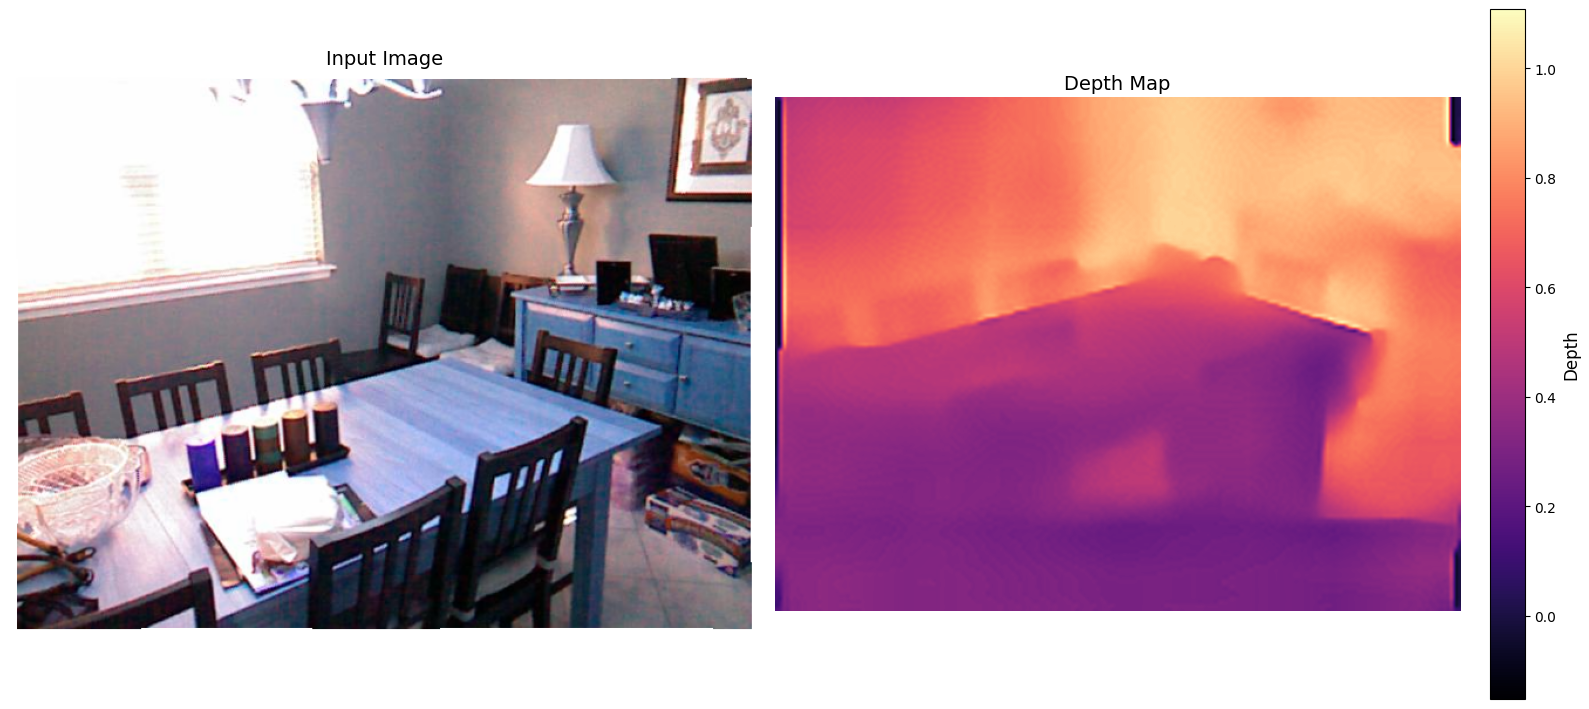

Results saved to depth_result_4.png and depth_only_4.png

Processing image 5/5: rgb_00272.png


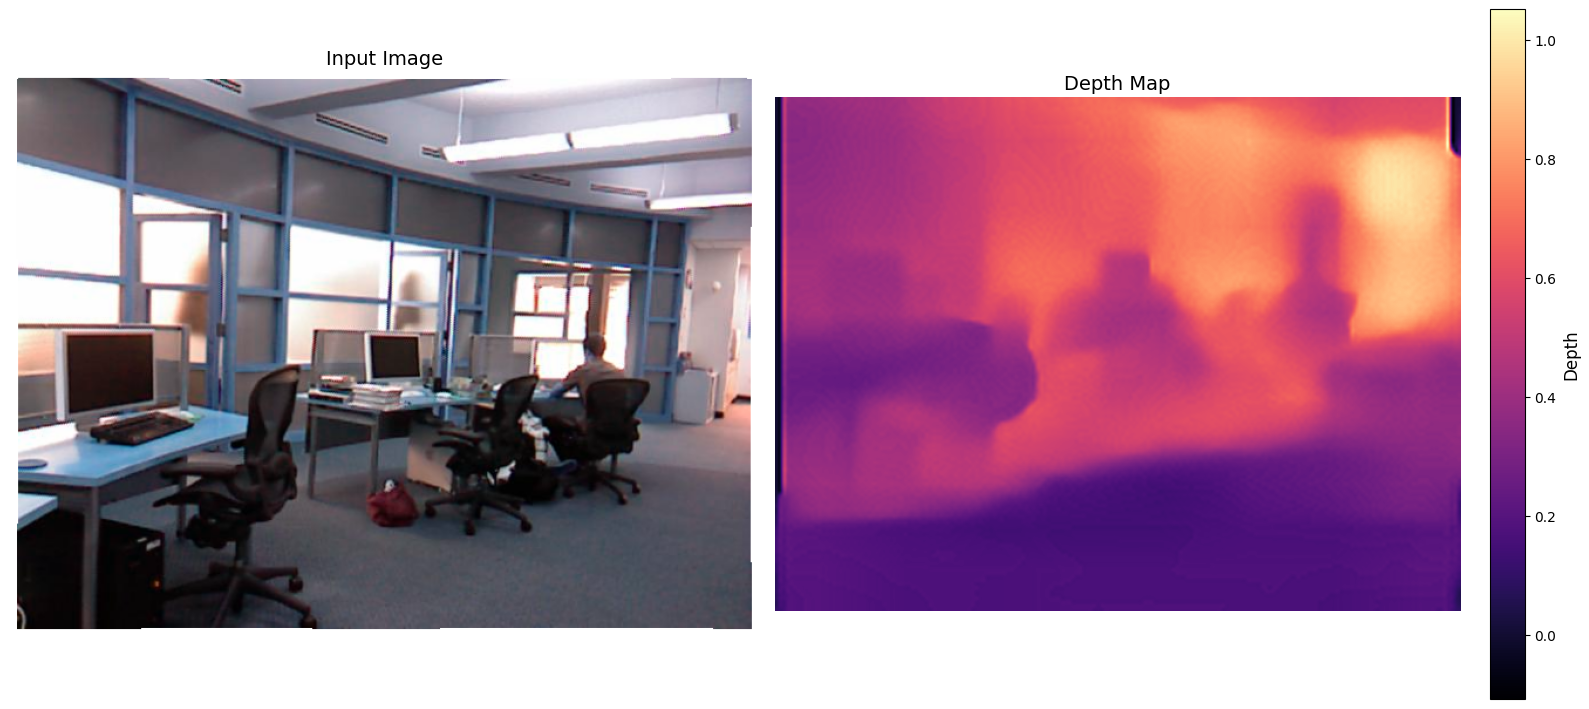

Results saved to depth_result_5.png and depth_only_5.png

Processing complete

Depth Estimation Options:
1. Process sample images
2. Process custom image(s)
3. Exit


In [ ]:
import torch
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
import random
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

config = {
    'dataset': {
        'image_size': 384,
        'batch_size': 1
    },
    'model': {
        'filters': 48  # Match training model filters (48 instead of 32)
    }
}

class ImprovedDepthModel(nn.Module):
    def __init__(self):
        super(ImprovedDepthModel, self).__init__()
        
        # Encoder part with double convolutions to match training model
        self.down1 = nn.Sequential(
            nn.Conv2d(3, config['model']['filters'], kernel_size=7, stride=2, padding=3),
            nn.BatchNorm2d(config['model']['filters']),
            nn.ReLU(inplace=True),
            nn.Conv2d(config['model']['filters'], config['model']['filters'], kernel_size=3, padding=1),
            nn.BatchNorm2d(config['model']['filters']),
            nn.ReLU(inplace=True)
        )
        self.pool1 = nn.MaxPool2d(2)
        
        self.down2 = nn.Sequential(
            nn.Conv2d(config['model']['filters'], config['model']['filters']*2, kernel_size=3, padding=1),
            nn.BatchNorm2d(config['model']['filters']*2),
            nn.ReLU(inplace=True),
            nn.Conv2d(config['model']['filters']*2, config['model']['filters']*2, kernel_size=3, padding=1),
            nn.BatchNorm2d(config['model']['filters']*2),
            nn.ReLU(inplace=True)
        )
        self.pool2 = nn.MaxPool2d(2)
        
        self.down3 = nn.Sequential(
            nn.Conv2d(config['model']['filters']*2, config['model']['filters']*4, kernel_size=3, padding=1),
            nn.BatchNorm2d(config['model']['filters']*4),
            nn.ReLU(inplace=True),
            nn.Conv2d(config['model']['filters']*4, config['model']['filters']*4, kernel_size=3, padding=1),
            nn.BatchNorm2d(config['model']['filters']*4),
            nn.ReLU(inplace=True)
        )
        self.pool3 = nn.MaxPool2d(2)
        
        self.down4 = nn.Sequential(
            nn.Conv2d(config['model']['filters']*4, config['model']['filters']*8, kernel_size=3, padding=1),
            nn.BatchNorm2d(config['model']['filters']*8),
            nn.ReLU(inplace=True),
            nn.Conv2d(config['model']['filters']*8, config['model']['filters']*8, kernel_size=3, padding=1),
            nn.BatchNorm2d(config['model']['filters']*8),
            nn.ReLU(inplace=True)
        )
        self.pool4 = nn.MaxPool2d(2)
        
        # Bottleneck - match training model
        self.bottleneck = nn.Sequential(
            nn.Conv2d(config['model']['filters']*8, config['model']['filters']*16, kernel_size=3, padding=1),
            nn.BatchNorm2d(config['model']['filters']*16),
            nn.ReLU(inplace=True),
            nn.Conv2d(config['model']['filters']*16, config['model']['filters']*16, kernel_size=3, padding=1),
            nn.BatchNorm2d(config['model']['filters']*16),
            nn.ReLU(inplace=True)
        )
        
        # Decoder part with skip connections - match training model
        self.up4 = nn.ConvTranspose2d(config['model']['filters']*16, config['model']['filters']*8, kernel_size=4, stride=2, padding=1)
        self.conv4 = nn.Sequential(
            nn.Conv2d(config['model']['filters']*16, config['model']['filters']*8, kernel_size=3, padding=1),
            nn.BatchNorm2d(config['model']['filters']*8),
            nn.ReLU(inplace=True),
            nn.Conv2d(config['model']['filters']*8, config['model']['filters']*8, kernel_size=3, padding=1),
            nn.BatchNorm2d(config['model']['filters']*8),
            nn.ReLU(inplace=True)
        )
        
        self.up3 = nn.ConvTranspose2d(config['model']['filters']*8, config['model']['filters']*4, kernel_size=4, stride=2, padding=1)
        self.conv3 = nn.Sequential(
            nn.Conv2d(config['model']['filters']*8, config['model']['filters']*4, kernel_size=3, padding=1),
            nn.BatchNorm2d(config['model']['filters']*4),
            nn.ReLU(inplace=True),
            nn.Conv2d(config['model']['filters']*4, config['model']['filters']*4, kernel_size=3, padding=1),
            nn.BatchNorm2d(config['model']['filters']*4),
            nn.ReLU(inplace=True)
        )
        
        self.up2 = nn.ConvTranspose2d(config['model']['filters']*4, config['model']['filters']*2, kernel_size=4, stride=2, padding=1)
        self.conv2 = nn.Sequential(
            nn.Conv2d(config['model']['filters']*4, config['model']['filters']*2, kernel_size=3, padding=1),
            nn.BatchNorm2d(config['model']['filters']*2),
            nn.ReLU(inplace=True),
            nn.Conv2d(config['model']['filters']*2, config['model']['filters']*2, kernel_size=3, padding=1),
            nn.BatchNorm2d(config['model']['filters']*2),
            nn.ReLU(inplace=True)
        )
        
        self.up1 = nn.ConvTranspose2d(config['model']['filters']*2, config['model']['filters'], kernel_size=4, stride=2, padding=1)
        self.conv1 = nn.Sequential(
            nn.Conv2d(config['model']['filters']*2, config['model']['filters'], kernel_size=3, padding=1),
            nn.BatchNorm2d(config['model']['filters']),
            nn.ReLU(inplace=True),
            nn.Conv2d(config['model']['filters'], config['model']['filters'], kernel_size=3, padding=1),
            nn.BatchNorm2d(config['model']['filters']),
            nn.ReLU(inplace=True)
        )
        
        # Output with more refinement - match training model
        self.output = nn.Sequential(
            nn.Conv2d(config['model']['filters'], config['model']['filters']//2, kernel_size=3, padding=1),
            nn.BatchNorm2d(config['model']['filters']//2),
            nn.ReLU(inplace=True),
            nn.Conv2d(config['model']['filters']//2, config['model']['filters']//4, kernel_size=3, padding=1),
            nn.BatchNorm2d(config['model']['filters']//4),
            nn.ReLU(inplace=True),
            nn.Conv2d(config['model']['filters']//4, 1, kernel_size=1),
            nn.Sigmoid()
        )
        
        # Initialize weights to match training model
        self._init_weights()
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.ConvTranspose2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        if x.size(2) != config['dataset']['image_size'] or x.size(3) != config['dataset']['image_size']:
            x = F.interpolate(x, size=(config['dataset']['image_size'], config['dataset']['image_size']), 
                             mode='bilinear', align_corners=True)
        
        # Encoder path
        d1 = self.down1(x)
        p1 = self.pool1(d1)
        
        d2 = self.down2(p1)
        p2 = self.pool2(d2)
        
        d3 = self.down3(p2)
        p3 = self.pool3(d3)
        
        d4 = self.down4(p3)
        p4 = self.pool4(d4)
        
        # Bottleneck
        b = self.bottleneck(p4)
        
        # Decoder path with skip connections
        u4 = self.up4(b)
        u4 = torch.cat([u4, d4], dim=1)
        c4 = self.conv4(u4)
        
        u3 = self.up3(c4)
        u3 = torch.cat([u3, d3], dim=1)
        c3 = self.conv3(u3)
        
        u2 = self.up2(c3)
        u2 = torch.cat([u2, d2], dim=1)
        c2 = self.conv2(u2)
        
        u1 = self.up1(c2)
        u1 = torch.cat([u1, d1], dim=1)
        c1 = self.conv1(u1)
        
        # Final output
        out = self.output(c1)
        
        return out

def load_model():
    
    model = ImprovedDepthModel().to(device)  # Use the improved model
    if os.path.exists('best_depth_model.pth'):
        model.load_state_dict(torch.load('best_depth_model.pth', map_location=device))
        print(f"Model loaded successfully")
        model.eval()
        return model
        
    print("Model file not found")
    return None

def better_enhance_depth(depth):
    """
    Enhanced depth map enhancement that preserves edges and reduces blocky artifacts
    """
    # Step 1: Normalize depth map
    depth_min = depth.min()
    depth_max = depth.max()
    if depth_max > depth_min:
        depth = (depth - depth_min) / (depth_max - depth_min)
    
    try:
        # Step 2: Apply bilateral filter to smooth while preserving edges
        # This is key to reducing the "boxy" artifacts
        depth_smooth = cv2.bilateralFilter(depth.astype(np.float32), d=7, sigmaColor=0.1, sigmaSpace=5)
        
        # Step 3: Convert to uint8 for processing
        depth_uint8 = (depth_smooth * 255).astype(np.uint8)
        
        # Step 4: Enhance local contrast with CLAHE
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        depth_contrast = clahe.apply(depth_uint8)
        depth_contrast = depth_contrast.astype(np.float32) / 255.0
        
        # Step 5: Enhance edges to make objects more visible
        kernel_edge = np.array([[0, -1, 0], 
                                [-1, 6, -1], 
                                [0, -1, 0]], dtype=np.float32)
        depth_edge = cv2.filter2D(depth_contrast, -1, kernel_edge)
        
        # Step 6: Blend original and enhanced versions
        depth_blend = 0.7 * depth_edge + 0.3 * depth_smooth
        
        # Step 7: Final gentle smoothing to reduce any noise
        depth_final = cv2.GaussianBlur(depth_blend, (3, 3), 0.5)
        
    except Exception as e:
        print(f"Error in depth enhancement: {e}")
        depth_final = depth  # Fallback to original if enhancement fails
    
    return np.clip(depth_final, 0, 1)

def predict_depth(model, image_path):
    img_size = config['dataset']['image_size']
    
    # Load image
    img = cv2.imread(image_path)
    if img is None:
        print(f"Could not read image: {image_path}")
        return None
    
    # Convert to RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Preserve aspect ratio (important to avoid distortion)
    h, w, _ = img.shape
    ratio = img_size / max(h, w)
    new_h, new_w = int(h * ratio), int(w * ratio)
    
    # Resize with cubic interpolation for better quality
    img_resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_CUBIC)
    
    # Create square image with padding
    square_img = np.zeros((img_size, img_size, 3), dtype=np.uint8)
    offset_h, offset_w = (img_size - new_h) // 2, (img_size - new_w) // 2
    square_img[offset_h:offset_h+new_h, offset_w:offset_w+new_w] = img_resized
    
    # Convert to tensor and normalize
    img_tensor = torch.from_numpy(square_img).float().permute(2, 0, 1) / 255.0
    img_tensor = img_tensor.unsqueeze(0).to(device)
    
    # Run inference
    with torch.no_grad():
        depth = model(img_tensor)
    
    # Post-process
    depth = depth.squeeze().cpu().numpy()
    
    # Apply improved depth enhancement
    depth_enhanced = better_enhance_depth(depth)
    
    # If image was padded, crop back to original aspect ratio
    if h != w:
        depth_enhanced = depth_enhanced[offset_h:offset_h+new_h, offset_w:offset_w+new_w]
        # Resize back to original dimensions if needed
        depth_enhanced = cv2.resize(depth_enhanced, (w, h), interpolation=cv2.INTER_CUBIC)
    
    return depth_enhanced

def process_images(model, image_dir, max_images=5):
    print(f"\nChecking directory: {image_dir}")
    
    if not os.path.exists(image_dir):
        print(f"Directory not found: {image_dir}")
        return
    
    image_files = [f for f in os.listdir(image_dir) 
                  if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    random.shuffle(image_files)
    if not image_files:
        print("No images found")
        return
    
    print(f"Found {len(image_files)} images")
    
    n_images = min(max_images, len(image_files))
    
    for i, image_file in enumerate(image_files[:n_images]):
        print(f"\nProcessing image {i+1}/{n_images}: {image_file}")
        image_path = os.path.join(image_dir, image_file)
        
        # Process image
        depth_map = predict_depth(model, image_path)
        if depth_map is None:
            continue
            
        # Load original image for display
        img = cv2.imread(image_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Save paths
        save_path = f"depth_result_{i+1}.png"
        
        # Create comparison visualization
        plt.figure(figsize=(16, 8))
        
        plt.subplot(1, 2, 1)
        plt.imshow(img)
        plt.title('Input Image', fontsize=14)
        plt.axis('off')
        
        plt.subplot(1, 2, 2)
        # Use magma colormap which provides better depth perception
        depth_img = plt.imshow(depth_map, cmap='magma')
        cbar = plt.colorbar(depth_img, fraction=0.046, pad=0.04)
        cbar.set_label('Depth', fontsize=12)
        plt.title('Depth Map', fontsize=14)
        plt.axis('off')
        
        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()
        
        # Save depth-only visualization
        plt.figure(figsize=(10, 10))
        plt.imshow(depth_map, cmap='magma')
        plt.axis('off')
        plt.tight_layout(pad=0)
        plt.savefig(f"depth_only_{i+1}.png", bbox_inches='tight', pad_inches=0, dpi=300)
        plt.close()
        
        print(f"Results saved to {save_path} and depth_only_{i+1}.png")
    
    print("\nProcessing complete")

def process_custom_images(model, image_paths):
    if not isinstance(image_paths, list):
        image_paths = [image_paths]
    
    print(f"\nProcessing {len(image_paths)} custom images")
    
    for i, image_path in enumerate(image_paths):
        if not os.path.exists(image_path):
            print(f"Image not found: {image_path}")
            continue
            
        print(f"\nProcessing image {i+1}/{len(image_paths)}: {os.path.basename(image_path)}")
        
        # Process image
        depth_map = predict_depth(model, image_path)
        if depth_map is None:
            continue
            
        # Load original image for display
        img = cv2.imread(image_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Save paths
        save_path = f"custom_depth_{i+1}.png"
        
        # Create comparison visualization
        plt.figure(figsize=(16, 8))
        
        plt.subplot(1, 2, 1)
        plt.imshow(img)
        plt.title('Input Image', fontsize=14)
        plt.axis('off')
        
        plt.subplot(1, 2, 2)
        # Use magma colormap which provides better depth perception
        depth_img = plt.imshow(depth_map, cmap='magma')
        cbar = plt.colorbar(depth_img, fraction=0.046, pad=0.04)
        cbar.set_label('Depth', fontsize=12)
        plt.title('Depth Map', fontsize=14)
        plt.axis('off')
        
        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()
        
        # Save depth-only visualization
        plt.figure(figsize=(10, 10))
        plt.imshow(depth_map, cmap='magma')
        plt.axis('off')
        plt.tight_layout(pad=0)
        plt.savefig(f"custom_depth_only_{i+1}.png", bbox_inches='tight', pad_inches=0, dpi=300)
        plt.close()
        
        print(f"Results saved to {save_path} and custom_depth_only_{i+1}.png")
    
    print("\nCustom processing complete")

if __name__ == "__main__":
    if not os.path.exists('test_images'):
        os.makedirs('test_images')
        print("Created test_images directory")

    print("Starting depth estimation process...")
    
    model = load_model()
    if model is None:
        print("Error: Could not load model")
        exit(1)
    
    while True:
        print("\nDepth Estimation Options:")
        print("1. Process sample images")
        print("2. Process custom image(s)")
        print("3. Exit")
        
        choice = input("Enter choice (1-3): ").strip()
        
        if choice == '1':
            input_images_dir = '/kaggle/input/nyuv2-official-split-dataset/test/official'
            if os.path.exists(input_images_dir):
                print(f"\nProcessing sample images from dataset")
                process_images(model, input_images_dir, max_images=8)
            elif os.path.exists('test_images') and any(f.endswith(('.jpg', '.png', '.jpeg')) for f in os.listdir('test_images')):
                print("\nProcessing images from test_images directory")
                process_images(model, 'test_images', max_images=5)
            else:
                print("No test images found")
        
        elif choice == '2':
            print("\nEnter image path(s), separated by commas:")
            custom_paths = input().strip()
            
            if not custom_paths:
                print("No paths entered")
                continue
                
            image_paths = [path.strip() for path in custom_paths.split(',')]
            process_custom_images(model, image_paths)
        
        elif choice == '3':
            print("Exiting")
            break
            
        else:
            print("Invalid choice")
            
    print("\nProcess completed")